# Chapter 2 — Data

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

> *"You can have data without information, but you cannot have information without data."*
> — Daniel Keys Moran

Chapter 1 argued that big data is data at a scale where the tools break. This chapter goes back a step and
looks hard at the raw material itself. It is the least glamorous chapter in the course and quietly the most
important: nearly every serious analytical mistake you will ever make traces back to misunderstanding what a
column actually *is*.

### Learning objectives

By the end of this chapter you should be able to:

1. **Define data** precisely, and place any dataset on the DIKW ladder from raw facts to an actionable decision.
2. **Identify data types** — quantitative vs. qualitative, discrete vs. continuous, nominal vs. ordinal — and
   say which statistics each one permits.
3. **Know the key features of data** — observations, variables, the data matrix — and identify where a dataset
   came from and what that origin implies about its trustworthiness.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1 | What data is, and the eight everyday kinds from the lecture |
| 2 | The DIKW pyramid, climbed with three grocery receipts (support, confidence, lift) |
| 3 | Data types: quantitative/qualitative, discrete/continuous, nominal/ordinal, binary |
| 4 | The four scales of measurement — and which arithmetic each one allows |
| 5 | Observations, variables, the data matrix, and tidy data |
| 6 | Data sources: primary vs. secondary, and how each is collected |
| 7 | Sampling — why *how* the data was collected can outweigh how much of it there is |
| 8 | Data ethics and personal data |
| 9–11 | Glossary, self-check quiz, summary |
| 12 | Graded homework 📝 |

In [1]:
# Run this cell first — everything below depends on it.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(888102)   # fixed seed: identical numbers for every student

print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.5


---
## 1. What is data?

**Data** is a collection of facts in a raw or unorganized form — numbers or characters — collected by
observation or experimentation.

Two words in that definition do a lot of work:

- **Raw.** Data has not yet been interpreted. `50200` is data; "the postal code of Mueang Chiang Mai" is
  information.
- **Collected.** Data does not simply exist — somebody or something *chose* to record it, chose what to
  record, and chose what to leave out. Every dataset carries the fingerprints of the person who collected it,
  which is why Sections 6 and 7 of this chapter matter as much as the type definitions.

The lecture lists eight everyday examples. They look like a random assortment; they are not. Sorting them by
type is the whole agenda of this chapter, so let's do it now and then spend the chapter justifying it.

In [2]:
# The eight examples from the lecture slide, classified. Everything in Sections 3 and 4 explains this table.
examples = pd.DataFrame([
    ("Opinion",     "Qualitative", "Ordinal",    "Ordinal",  "'Agree' ranks above 'Neutral', but by how much is undefined"),
    ("Distance",    "Quantitative", "Continuous", "Ratio",   "0 km really means no distance; 10 km is twice 5 km"),
    ("Temperature", "Quantitative", "Continuous", "Interval","0 °C does not mean 'no temperature' — see Section 4.2"),
    ("Score",       "Quantitative", "Continuous", "Interval","Differences are meaningful; ratios usually are not"),
    ("Gender",      "Qualitative",  "Nominal",    "Nominal", "Categories with no order at all"),
    ("Weight",      "Quantitative", "Continuous", "Ratio",   "A true zero, so 'twice as heavy' is meaningful"),
    ("Date",        "Quantitative", "Continuous", "Interval","Differences (days between) work; ratios do not"),
    ("Currency",    "Qualitative",  "Nominal",    "Nominal", "THB vs USD is a label — the *amount* is the ratio variable"),
], columns=["Example", "Quantitative / qualitative", "Sub-type", "Scale", "Why"])

examples

,Example,Quantitative / qualitative,Sub-type,Scale,Why
0,Opinion,Qualitative,Ordinal,Ordinal,"'Agree' ranks above 'Neutral', but by how much..."
1,Distance,Quantitative,Continuous,Ratio,0 km really means no distance; 10 km is twice ...
2,Temperature,Quantitative,Continuous,Interval,0 °C does not mean 'no temperature' — see Sect...
3,Score,Quantitative,Continuous,Interval,Differences are meaningful; ratios usually are...
4,Gender,Qualitative,Nominal,Nominal,Categories with no order at all
5,Weight,Quantitative,Continuous,Ratio,"A true zero, so 'twice as heavy' is meaningful"
6,Date,Quantitative,Continuous,Interval,Differences (days between) work; ratios do not
7,Currency,Qualitative,Nominal,Nominal,THB vs USD is a label — the *amount* is the ra...


**How to read it:** notice the two entries that surprise people. **Currency** here means the currency *name*
(THB, USD, JPY) — a label with no order — while the *amount of money* is a ratio variable. And **temperature**
in Celsius is interval, not ratio, because its zero point was chosen by a person rather than found in nature.
Section 4.2 shows exactly what goes wrong if you forget that.

---
## 2. The DIKW pyramid — from data to wisdom

Each building block is a step toward a higher level, climbing from raw facts to a decision you can act on:

| Level | Definition (from the lecture) |
|---|---|
| **Wisdom** | The ability to select objectives consistent with a general set of values |
| **Knowledge** | The ability to use information tactically and strategically to achieve specified objectives |
| **Information** | Data that has been processed and structured, adding context and increased meaning |
| **Data** | Raw, unprocessed facts and/or figures, often obtained via measurement instruments |

The lecture climbs this ladder with three grocery receipts. We will do the same, one code cell per level, so
you can see the exact moment the data turns into something else.

In [3]:
# Level 1 — DATA: three raw receipts. Just facts, no meaning attached yet.
receipts = [
    ["apple", "banana", "strawberry", "pineapple"],
    ["avocado", "grape", "apple", "banana"],
    ["orange", "apple", "banana", "papaya"],
]
for i, receipt in enumerate(receipts, start=1):
    print(f"Receipt {i}: {receipt}")

print(f"\n{len(receipts)} receipts, "
      f"{len({item for receipt in receipts for item in receipt})} distinct items.")

Receipt 1: ['apple', 'banana', 'strawberry', 'pineapple']
Receipt 2: ['avocado', 'grape', 'apple', 'banana']
Receipt 3: ['orange', 'apple', 'banana', 'papaya']

3 receipts, 8 distinct items.


**How to read it:** there is nothing here to act on. You cannot answer "what should we do?" or even "what is
going on?" from three lists of fruit. That is what "raw" means.

In [4]:
# Level 2 — INFORMATION: structure the raw facts so they can be queried.
# How often does each pair of items appear together on the same receipt?
co_occurrence = {}
for receipt in receipts:
    for item_a, item_b in combinations(sorted(set(receipt)), 2):
        co_occurrence[(item_a, item_b)] = co_occurrence.get((item_a, item_b), 0) + 1

co_df = (pd.DataFrame([(a, b, n) for (a, b), n in co_occurrence.items()],
                      columns=["item_A", "item_B", "receipts_together"])
         .sort_values("receipts_together", ascending=False)
         .reset_index(drop=True))

print(f"{len(co_df)} distinct pairs across {len(receipts)} receipts.\n")
co_df.head(8)

16 distinct pairs across 3 receipts.



,item_A,item_B,receipts_together
0,apple,banana,3
1,apple,pineapple,1
2,apple,strawberry,1
3,banana,pineapple,1
4,banana,strawberry,1
5,pineapple,strawberry,1
6,apple,avocado,1
7,apple,grape,1


**How to read it:** every column here came from *organizing* the raw receipts — nothing new was measured. That
reorganization is precisely the data → information step. "Apple and banana occur together on all three
receipts" is now visible as a pattern; it was equally true before, but invisible.

In [5]:
# Level 3 — KNOWLEDGE: turn the strongest pattern into an if-then rule with a number attached.
top_pair = co_df.iloc[0]
item_a, item_b = top_pair["item_A"], top_pair["item_B"]
confidence = top_pair["receipts_together"] / len(receipts)

print(f"Rule: IF a customer buys {item_a}, THEN they often also buy {item_b}.")
print(f"Confidence: {confidence:.0%} of receipts support this rule.")

Rule: IF a customer buys apple, THEN they often also buy banana.
Confidence: 100% of receipts support this rule.


### 2.1 Three numbers, not one — support, confidence, and lift

Confidence alone can badly mislead you, and it is worth seeing why now rather than in Chapter 12. An
association rule *A → B* is normally judged on three numbers:

| Measure | Formula | Question it answers |
|---|---|---|
| **Support** | P(A and B) | How often does this pair happen at all? |
| **Confidence** | P(B given A) | When A is bought, how often is B too? |
| **Lift** | P(B given A) / P(B) | Does buying A make B *more likely than usual*? |

**Lift is the one that keeps you honest.** If a shop sells bananas on 95% of receipts, then "apple → banana"
with 95% confidence tells you nothing — bananas are on almost every receipt regardless. Lift divides by that
baseline: lift > 1 means a genuine association, lift ≈ 1 means coincidence, lift < 1 means A and B actually
*repel* each other.

In [6]:
def rule_metrics(antecedent, consequent, baskets):
    n = len(baskets)
    n_a = sum(1 for b in baskets if antecedent in b)
    n_b = sum(1 for b in baskets if consequent in b)
    n_ab = sum(1 for b in baskets if antecedent in b and consequent in b)
    support = n_ab / n
    conf = n_ab / n_a if n_a else np.nan
    lift = conf / (n_b / n) if n_b else np.nan
    return {"rule": f"{antecedent} -> {consequent}", "support": round(support, 3),
            "confidence": round(conf, 3), "lift": round(lift, 3)}

rules = pd.DataFrame([rule_metrics(a, b, receipts) for a, b in
                      [("apple", "banana"), ("banana", "apple"),
                       ("apple", "orange"), ("grape", "avocado")]])
rules

,rule,support,confidence,lift
0,apple -> banana,1.000,1.000,1.0
1,banana -> apple,1.000,1.000,1.0
2,apple -> orange,0.333,0.333,1.0
3,grape -> avocado,0.333,1.000,3.0


**How to read it:** `apple -> banana` has support 1.0, confidence 1.0, and lift 1.0. The first two look
spectacular; the third deflates them. Lift is exactly 1 because **banana appears on every receipt anyway** —
knowing that someone bought an apple does not raise the chance of a banana at all, because that chance was
already 100%.

This is the single most common misreading of a "customers who bought X also bought Y" statistic, and three
receipts is not nearly enough data to escape it. Let's see what a larger, more realistic basket set looks
like.

In [7]:
# Simulate 2,000 receipts where a real association exists: coffee and pastry genuinely go together,
# while bread is simply popular with everyone.
n_baskets = 2_000
sim_baskets = []
for _ in range(n_baskets):
    basket = set()
    if rng.random() < 0.80:                       # bread: very common, unrelated to anything
        basket.add("bread")
    buys_coffee = rng.random() < 0.30
    if buys_coffee:
        basket.add("coffee")
        if rng.random() < 0.65:                   # coffee buyers often add a pastry
            basket.add("pastry")
    elif rng.random() < 0.10:                     # non-coffee buyers rarely do
        basket.add("pastry")
    if rng.random() < 0.25:
        basket.add("milk")
    sim_baskets.append(basket)

sim_rules = pd.DataFrame([rule_metrics(a, b, sim_baskets) for a, b in
                          [("coffee", "pastry"), ("coffee", "bread"),
                           ("pastry", "coffee"), ("milk", "bread")]])
sim_rules

,rule,support,confidence,lift
0,coffee -> pastry,0.199,0.646,2.420
1,coffee -> bread,0.247,0.802,0.997
2,pastry -> coffee,0.199,0.745,2.420
3,milk -> bread,0.206,0.791,0.984


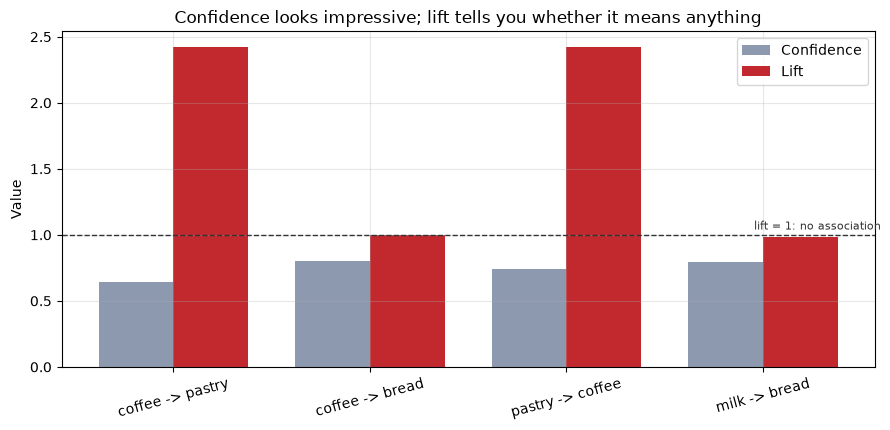

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(sim_rules))
width = 0.38
ax.bar(x - width / 2, sim_rules["confidence"], width, label="Confidence", color="#8D99AE")
ax.bar(x + width / 2, sim_rules["lift"], width, label="Lift", color="#C1292E")
ax.axhline(1.0, color="#333", linestyle="--", linewidth=1)
ax.text(len(sim_rules) - 0.4, 1.04, "lift = 1: no association", fontsize=8, ha="right", color="#333")
ax.set_xticks(x, sim_rules["rule"], rotation=15)
ax.set_ylabel("Value")
ax.set_title("Confidence looks impressive; lift tells you whether it means anything")
ax.legend()
plt.show()

**How to read it:** `coffee -> bread` has high *confidence* (about 0.8 — most coffee buyers do buy bread) but
lift almost exactly 1, because 80% of *everyone* buys bread. It is a real co-occurrence and a worthless rule.
`coffee -> pastry` has lower confidence but lift well above 1: coffee buyers really are several times more
likely than average to buy a pastry. Only the second rule justifies moving anything on a shelf.

In [9]:
# Level 4 — WISDOM: use the rule to choose an action, consistent with the business's objectives.
best = sim_rules.sort_values("lift", ascending=False).iloc[0]

if best["lift"] > 1.2 and best["support"] > 0.05:
    print(f"Recommendation: act on '{best['rule']}'.")
    print(f"  Lift {best['lift']:.2f} means the pairing is {best['lift']:.1f}x more likely than chance,")
    print(f"  and support {best['support']:.1%} means it affects enough receipts to be worth the shelf space.")
    print("  Action: place the two next to each other, or bundle them as a set price.")
else:
    print("Recommendation: no rule is both strong and common enough to act on. Collect more data.")

Recommendation: act on 'coffee -> pastry'.
  Lift 2.42 means the pairing is 2.4x more likely than chance,
  and support 19.9% means it affects enough receipts to be worth the shelf space.
  Action: place the two next to each other, or bundle them as a set price.


**How to read it:** the decision rule needs *both* numbers. High lift with tiny support is a real pattern
affecting almost nobody — statistically interesting, commercially pointless. High support with lift near 1 is
a common coincidence. Requiring both is a business judgment, and that judgment — not the arithmetic — is the
wisdom level of the pyramid.

> ✏️ **Try it:** add a fourth receipt of your own to the original `receipts` list (e.g.
> `["apple", "orange", "grape"]`) and re-run the Level 2 and Level 3 cells. Does the confidence for
> apple → banana go up or down? Now re-run the `rule_metrics` cell — what happens to the *lift*, and why does
> it move in a different direction from confidence?

---
## 3. Data types

The first fork in the road for any variable: **is it a number, or a category?**

| | **Quantitative (numerical)** | **Qualitative (categorical)** |
|---|---|---|
| Measures | Values or counts | Types |
| Asks | *How many? How much? How often?* | *What type?* |
| Examples | temperature, weight, score, time, distance | gender, currency, competition level, scent, color |

Each branch then splits again, giving four types in total:

```
                        DATA
                         |
          +--------------+--------------+
          |                             |
   QUANTITATIVE                    QUALITATIVE
   (numbers)                       (categories)
          |                             |
    +-----+-----+                 +-----+-----+
    |           |                 |           |
 DISCRETE   CONTINUOUS        NOMINAL     ORDINAL
 (counted)  (measured)      (no order)   (ordered)
```

### 3.1 Quantitative data — discrete vs. continuous

Both are numbers, but they behave differently: one you can **count**, the other you can only **measure**.

- **Discrete** — assumes only a finite or countable number of values. The number of students in a class, books
  in a library, product reviews, files in a folder.
- **Continuous** — assumes infinitely many values on an interval. The weight of a parcel, a fridge's
  temperature, an exam score, the distance to the Moon.

The reliable test is: **can a value halfway between two observed values exist?** 24.5 students cannot; 58.35 kg
can.

In [10]:
# The lecture's worked example: both kinds in one table.
class_data = pd.DataFrame({
    "num_students": [24, 31, 18, 27],           # discrete: there is no such thing as 24.5 students
    "avg_weight_kg": [58.3, 62.1, 55.7, 60.9],  # continuous: 58.34, 58.341, ... all make sense
})

print(class_data.dtypes, "\n")
class_data

num_students       int64
avg_weight_kg    float64
dtype: object 



,num_students,avg_weight_kg
0,24,58.3
1,31,62.1
2,18,55.7
3,27,60.9


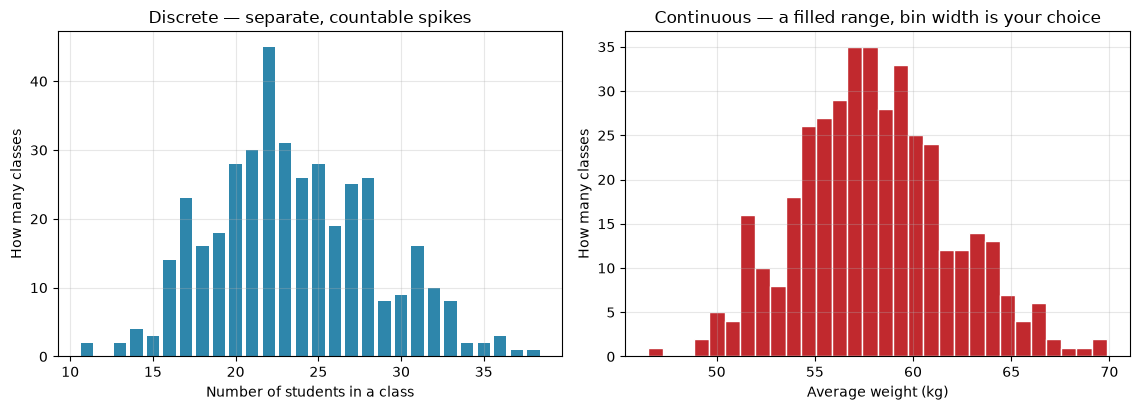

In [11]:
# The same distinction, drawn. Discrete values sit on separate spikes; continuous values fill a range.
discrete_sample = rng.poisson(24, 400)                  # class sizes
continuous_sample = rng.normal(58.3, 4.0, 400)          # weights in kg

fig, (ax_d, ax_c) = plt.subplots(1, 2, figsize=(11.5, 4.2))

values, counts = np.unique(discrete_sample, return_counts=True)
ax_d.bar(values, counts, color="#2E86AB", width=0.75)
ax_d.set_xlabel("Number of students in a class")
ax_d.set_ylabel("How many classes")
ax_d.set_title("Discrete — separate, countable spikes")

ax_c.hist(continuous_sample, bins=30, color="#C1292E", edgecolor="white")
ax_c.set_xlabel("Average weight (kg)")
ax_c.set_ylabel("How many classes")
ax_c.set_title("Continuous — a filled range, bin width is your choice")

plt.show()

**How to read it:** the left chart has a bar for each whole number and gaps between them, because no class has
23.5 students. The right chart has no gaps: the bin boundaries are a **choice you made**, not a property of
the data. Change `bins=30` to `bins=8` and the picture changes while the data does not — a first taste of a
theme Chapter 7 develops properly.

⚠️ **A trap:** when a discrete variable takes many values (say, page views per day, ranging from 0 to 50,000),
it is usually *treated* as continuous, because a histogram is more useful than 50,000 spikes. That is a
practical convenience, not a change in the variable's true type. It matters again the moment you try to model
it — count data has its own methods.

> ✏️ **Try it:** change `bins=30` to `bins=5`, then to `bins=100`. At which setting does the histogram start to
> tell you something false about the shape of the data?

### 3.2 Qualitative data — nominal vs. ordinal

Both are categories, but only one of them has a natural order.

- **Nominal** — labels with no numerical value that *cannot* be ordered: hair color, gender, scent, currency.
- **Ordinal** — labels with no numerical value that *do* follow a natural order: satisfaction level,
  competition rank, letter grades.

The distinction is not decoration. It decides whether "sort these" and "what is the median?" are legitimate
questions.

In [12]:
# Nominal: no natural order — pandas treats these as plain, unordered categories.
hair_color = pd.Categorical(["Brown", "Blonde", "Black", "Brown"])
print("Nominal (hair color) :", list(hair_color))
print("  ordered?", hair_color.ordered)
print("  categories:", list(hair_color.categories))

# Ordinal: has a natural order — we must state the order explicitly, because pandas cannot guess it.
satisfaction = pd.Categorical(
    ["Medium", "High", "Low", "High"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
print("\nOrdinal (satisfaction):", list(satisfaction))
print("  ordered?", satisfaction.ordered)
print("  Is 'High' > 'Medium'?", (satisfaction > "Medium")[1])

Nominal (hair color) : ['Brown', 'Blonde', 'Black', 'Brown']
  ordered? False
  categories: ['Black', 'Blonde', 'Brown']

Ordinal (satisfaction): ['Medium', 'High', 'Low', 'High']
  ordered? True
  Is 'High' > 'Medium'? True


In [13]:
# What happens if you try to order an unordered category?
try:
    _ = hair_color > "Blonde"
except TypeError as error:
    print("Comparing nominal categories raises an error, and that is the point:")
    print(" ", error)

print("\nBut sorting an ordinal category works exactly as you would hope:")
print(" ", list(satisfaction.sort_values()))

print("\nAnd notice how differently they summarize:")
print("  Nominal — only the mode is meaningful:", pd.Series(hair_color).mode().tolist())
print("  Ordinal — the median is meaningful too:",
      pd.Series(satisfaction).sort_values().iloc[len(satisfaction) // 2])

Comparing nominal categories raises an error, and that is the point:
  Unordered Categoricals can only compare equality or not

But sorting an ordinal category works exactly as you would hope:
  ['Low', 'Medium', 'High', 'High']

And notice how differently they summarize:
  Nominal — only the mode is meaningful: ['Brown']
  Ordinal — the median is meaningful too: High


**How to read it:** `hair_color.ordered` is `False`, so pandas *refuses* to compare two hair colors. That
refusal is a feature. "Brown" is not more or less than "Blonde," and a library that silently sorted them
alphabetically and called it an order would be helping you make a mistake.

Declaring your categories ordered is a small act of documentation that pays for itself: it lets pandas sort,
take medians, and plot in the right sequence, and it makes your assumption visible to the next reader.

⚠️ **The most common bug in this area** is an ordinal variable stored as text and then sorted alphabetically:
`High, Low, Medium` — which is neither the right order nor obviously wrong at a glance.

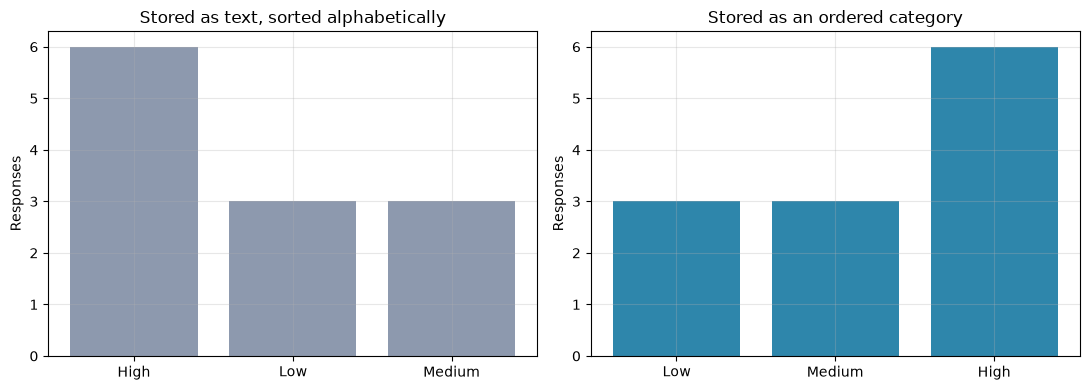

In [14]:
# The alphabetical-sort trap, side by side.
responses = ["High", "Low", "Medium", "High", "Low", "High", "Medium", "High", "Low", "Medium", "High", "High"]

as_text = pd.Series(responses).value_counts()                    # order: whatever value_counts gives
as_ordinal = pd.Series(pd.Categorical(responses, categories=["Low", "Medium", "High"],
                                      ordered=True)).value_counts().sort_index()

fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(11, 4))
ax_wrong.bar(sorted(as_text.index), [as_text[k] for k in sorted(as_text.index)], color="#8D99AE")
ax_wrong.set_title("Stored as text, sorted alphabetically")
ax_wrong.set_ylabel("Responses")

ax_right.bar(as_ordinal.index.astype(str), as_ordinal.values, color="#2E86AB")
ax_right.set_title("Stored as an ordered category")
ax_right.set_ylabel("Responses")

plt.show()

**How to read it:** identical data, two charts. The left one puts High before Low before Medium, so the
reader's eye reads a nonsense progression and cannot see that responses skew positive. The right one is
ordered Low → Medium → High and the skew is immediately obvious. Nothing was computed wrongly on the left; the
*type* was declared wrongly, and the chart inherited the mistake.

### 3.3 A special case worth naming: binary data

A variable with exactly two categories — yes/no, pass/fail, clicked/did not click, male/female — is called
**binary** or **dichotomous**. It is technically nominal, but it earns its own name because it has a useful
property no other nominal variable has: **you can encode it as 0/1 and the mean becomes meaningful**.

In [15]:
passed = pd.Series([1, 0, 1, 1, 1, 0, 1, 0, 1, 1])   # 1 = passed, 0 = failed

print("Mean of the 0/1 column:", passed.mean())
print("Proportion who passed :", (passed == 1).mean())
print("\nThey are the same number — that is the special property of binary data.")
print("Compare with a three-category variable encoded 1/2/3:")

grades = pd.Series([1, 3, 2, 1, 3])   # 1 = Low, 2 = Medium, 3 = High
print("  Mean =", grades.mean(), "-> 'the average grade is 2.0' means... Medium? Not really.")

Mean of the 0/1 column: 0.7
Proportion who passed : 0.7

They are the same number — that is the special property of binary data.
Compare with a three-category variable encoded 1/2/3:
  Mean = 2.0 -> 'the average grade is 2.0' means... Medium? Not really.


**How to read it:** for binary data the mean *is* the proportion, which is why "click-through rate," "pass
rate," and "conversion rate" are all just averages of 0/1 columns. For three or more ordered categories the
mean is not so innocent, which brings us to scales of measurement.

---
## 4. Scales of measurement — why the scale matters

Four scales, each allowing a different set of operations. This table is the most practically useful thing in
the chapter:

| Scale | Ordered? | Equal intervals? | True zero? | Example | Center you may report |
|---|---|---|---|---|---|
| **Nominal** | No | No | No | postal code, currency, blood type | Mode only |
| **Ordinal** | Yes | No | No | satisfaction, letter grade, rank | Mode, median |
| **Interval** | Yes | Yes | No | temperature (°C/°F), calendar date, IQ | Mode, median, mean |
| **Ratio** | Yes | Yes | Yes | weight, distance, income, age, count | Mode, median, mean, geometric mean |

Each row adds one capability to the row above it, and each capability unlocks specific arithmetic:

- **Ordered** → you can sort, rank, and take a median.
- **Equal intervals** → differences are meaningful, so you can add, subtract, and take a mean.
- **True zero** → *ratios* are meaningful, so "twice as much" finally means something.

### 4.1 The mean is only meaningful for interval and ratio data

In [16]:
# The lecture's example: a computer will average anything you hand it.
postal_codes = pd.Series([50200, 50210, 10330])   # nominal, despite being written with digits
weights_kg = pd.Series([58.3, 62.1, 55.7])        # ratio

print(f"Mean of postal codes : {postal_codes.mean():.1f}"
      "   <- a number, but meaningless: there is no 'average postal code'")
print(f"Mean of weights (kg) : {weights_kg.mean():.1f}"
      "     <- meaningful: the average weight")

print("\nWorse: 36913.3 is not even a real postal code. The arithmetic invented a place that does not exist.")

Mean of postal codes : 36913.3   <- a number, but meaningless: there is no 'average postal code'
Mean of weights (kg) : 58.7     <- meaningful: the average weight

Worse: 36913.3 is not even a real postal code. The arithmetic invented a place that does not exist.


**How to read it:** pandas will happily compute `.mean()` on *any* numeric column — it has no idea that postal
codes are secretly nominal. **Nothing in your software will stop you here.** Knowing the scale of measurement
is what tells *you*, the analyst, which statistics are meaningful and which are elaborate nonsense.

Watch for nominal data disguised as numbers: postal codes, student IDs, phone numbers, product SKUs, room
numbers, jersey numbers, ISBNs, and any "category 1 / category 2 / category 3" coding.

### 4.2 Interval vs. ratio — the Celsius trap

This is the distinction people get wrong most often, and it has a clean demonstration.

Celsius has **equal intervals** (the gap from 10 °C to 11 °C is the same amount of heat as 30 °C to 31 °C) but
**no true zero** — 0 °C is the freezing point of water, a point somebody chose, not an absence of heat.

Kelvin has a true zero: 0 K really is "no thermal energy at all."

So: is 30 °C twice as hot as 15 °C?

In [17]:
celsius = pd.Series([15.0, 30.0])
kelvin = celsius + 273.15          # the same two temperatures, on a ratio scale

print("In Celsius:")
print(f"  {celsius[1]:.1f} / {celsius[0]:.1f} = {celsius[1] / celsius[0]:.2f}  -> 'twice as hot'")
print("\nIn Kelvin (the same two temperatures):")
print(f"  {kelvin[1]:.2f} / {kelvin[0]:.2f} = {kelvin[1] / kelvin[0]:.3f}  -> only about 5% hotter")

print("\nThe difference, however, survives the conversion:")
print(f"  Celsius difference: {celsius[1] - celsius[0]:.1f}")
print(f"  Kelvin  difference: {kelvin[1] - kelvin[0]:.1f}")

In Celsius:
  30.0 / 15.0 = 2.00  -> 'twice as hot'

In Kelvin (the same two temperatures):
  303.15 / 288.15 = 1.052  -> only about 5% hotter

The difference, however, survives the conversion:
  Celsius difference: 15.0
  Kelvin  difference: 15.0


**How to read it:** the *ratio* changed from 2.00 to 1.05 just by changing units, so the ratio was never a
fact about the world — it was an artifact of where somebody put the zero. The *difference* stayed at exactly
15 degrees, because differences only need equal intervals, which both scales have.

That is the whole interval-vs-ratio distinction in one calculation: **on an interval scale, differences are
real and ratios are fiction.** The same caution applies to calendar dates (the year 2000 is not "twice" the
year 1000) and to most test scores.

In [18]:
# Which summary statistics are permitted at each scale?
permitted = pd.DataFrame({
    "Mode":            ["Yes", "Yes", "Yes", "Yes"],
    "Median":          ["No",  "Yes", "Yes", "Yes"],
    "Mean":            ["No",  "Debatable", "Yes", "Yes"],
    "Difference (A-B)":["No",  "No",  "Yes", "Yes"],
    "Ratio (A/B)":     ["No",  "No",  "No",  "Yes"],
    "Standard deviation": ["No", "No", "Yes", "Yes"],
}, index=["Nominal", "Ordinal", "Interval", "Ratio"])

permitted

,Mode,Median,Mean,Difference (A-B),Ratio (A/B),Standard deviation
Nominal,Yes,No,No,No,No,No
Ordinal,Yes,Yes,Debatable,No,No,No
Interval,Yes,Yes,Yes,Yes,No,Yes
Ratio,Yes,Yes,Yes,Yes,Yes,Yes


**How to read it:** the "Yes" region grows as you move down the table — each scale keeps everything the one
above it allowed and adds more. The single "Debatable" cell is real and worth knowing about.

**The Likert-scale argument.** Survey responses coded 1 = Strongly disagree … 5 = Strongly agree are strictly
ordinal: nothing guarantees that the gap between 1 and 2 equals the gap between 4 and 5. Purists therefore say
you may report a median but not a mean. In practice almost every published survey reports means anyway,
because a mean uses more of the information and is easier to compare across groups.

The defensible position is to know that you are making an assumption, state it, and check that your conclusion
does not depend on it — if the mean and the median disagree about which group scored higher, believe the
median.

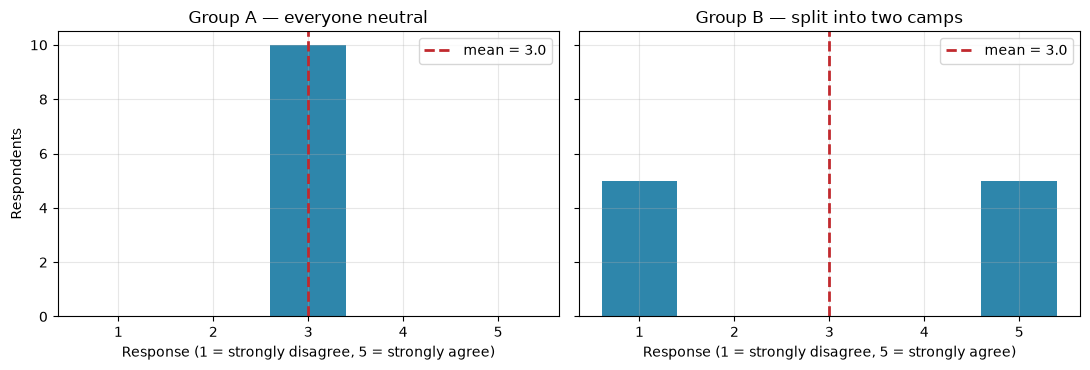

,Mean,Median,Std dev
Group A (all neutral),3.0,3.0,0.00
Group B (evenly split 1s and 5s),3.0,3.0,2.11


In [19]:
# When does averaging an ordinal scale mislead? When the distribution is not roughly symmetric.
group_a = pd.Series([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])    # everyone neutral
group_b = pd.Series([1, 1, 1, 1, 1, 5, 5, 5, 5, 5])    # violently split, nobody neutral

summary = pd.DataFrame({
    "Mean": [group_a.mean(), group_b.mean()],
    "Median": [group_a.median(), group_b.median()],
    "Std dev": [group_a.std().round(2), group_b.std().round(2)],
}, index=["Group A (all neutral)", "Group B (evenly split 1s and 5s)"])

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, group, title in [(ax_a, group_a, "Group A — everyone neutral"),
                         (ax_b, group_b, "Group B — split into two camps")]:
    counts = group.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
    ax.bar(counts.index, counts.values, color="#2E86AB")
    ax.axvline(group.mean(), color="#C1292E", linestyle="--", linewidth=2,
               label=f"mean = {group.mean():.1f}")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Response (1 = strongly disagree, 5 = strongly agree)")
    ax.set_title(title)
    ax.legend()
ax_a.set_ylabel("Respondents")
plt.show()

summary

**How to read it:** both groups have a mean of exactly 3.0 and a median of exactly 3.0, and they could hardly
be more different. Group A is genuinely indifferent; Group B is a company about to have an argument. The mean
described neither.

The lesson is broader than ordinal data: **a single summary number can be identical for wildly different
distributions.** Always look at the shape before you trust the average — which is exactly why Chapter 7 exists,
and why Chapter 8 spends time on dispersion rather than only on center.

---
## 5. Terminology — observations, variables, and the data matrix

- An **observation** (also *case*, *record*, *experimental unit*) is the person or thing on which measurements
  are taken. It becomes a **row**.
- A **variable** (also *feature*, *attribute*, *field*) is a measured characteristic of an observation. It
  becomes a **column**.
- A **data matrix** arranges variables as columns and observations as rows — which is exactly what a pandas
  `DataFrame` is.
- Each **cell** holds one value, for one variable, on one observation.

In [20]:
# Rebuilding the lecture's data matrix example.
data_matrix = pd.DataFrame({
    "ID": [248, 249, 250, 251, 252],
    "Sex": ["Male", "Female", "Male", "Male", "Female"],
    "Education": ["High School", "High School", "College", "Child", "High School"],
    "Income": [100000, 12000, 23000, 0, 19798],
})
data_matrix

,ID,Sex,Education,Income
0,248,Male,High School,100000
1,249,Female,High School,12000
2,250,Male,College,23000
3,251,Male,Child,0
4,252,Female,High School,19798


In [21]:
n_observations, n_variables = data_matrix.shape
print(f"Observations (rows)   : {n_observations}")
print(f"Variables   (columns) : {n_variables} -> {list(data_matrix.columns)}")

print("\nAnd the type of each variable, which is what Sections 3 and 4 were about:")
for column in data_matrix.columns:
    print(f"  {column:10s} dtype={str(data_matrix[column].dtype):8s}")

print("\nCareful: 'ID' is stored as an integer but is nominal — averaging it is meaningless.")
print(f"  Nonsense: mean ID = {data_matrix['ID'].mean():.1f}")
print(f"  Sensible: mean income = {data_matrix['Income'].mean():,.0f}")

Observations (rows)   : 5
Variables   (columns) : 4 -> ['ID', 'Sex', 'Education', 'Income']

And the type of each variable, which is what Sections 3 and 4 were about:
  ID         dtype=int64   
  Sex        dtype=str     
  Education  dtype=str     
  Income     dtype=int64   

Careful: 'ID' is stored as an integer but is nominal — averaging it is meaningless.
  Nonsense: mean ID = 250.0
  Sensible: mean income = 30,960


**How to read it:** `.shape` returns `(rows, columns)` — in data-matrix language, `(observations, variables)`.
Every row is one *person*; every column is one measured *characteristic* of that person.

Note the fourth row: `Education = "Child"`, `Income = 0`. That row is a reminder that a data matrix records
what was collected, not what is true. A zero income for a child is not a measurement of poverty, and any
analysis that averages incomes across this table without excluding children will produce a number that means
nothing. Deciding **who belongs in the table at all** is a bigger decision than any statistic you compute
from it.

### 5.1 Tidy data — the same numbers, arranged usefully

"One row per observation, one column per variable" sounds obvious until you see how often real data violates
it. The most common violation is **column headers that are values, not variable names**.

In [22]:
# A "wide" table: the year is spread across three column headers. Common in spreadsheets, awkward in code.
wide = pd.DataFrame({
    "Store": ["Nimman", "Old City", "Airport"],
    "2022": [1_200_000, 980_000, 1_540_000],
    "2023": [1_310_000, 1_020_000, 1_610_000],
    "2024": [1_450_000, 950_000, 1_720_000],
})
print("WIDE (not tidy) — '2022' is a value of a Year variable, not a variable name:")
wide

WIDE (not tidy) — '2022' is a value of a Year variable, not a variable name:


,Store,2022,2023,2024
0,Nimman,1200000,1310000,1450000
1,Old City,980000,1020000,950000
2,Airport,1540000,1610000,1720000


In [23]:
# The same data, tidied: every row is one store-year observation, every column is a variable.
tidy = wide.melt(id_vars="Store", var_name="Year", value_name="Revenue")
tidy["Year"] = tidy["Year"].astype(int)

print("TIDY — 3 stores x 3 years = 9 observations, 3 variables:")
print(f"  shape: {tidy.shape}\n")
tidy

TIDY — 3 stores x 3 years = 9 observations, 3 variables:
  shape: (9, 3)



,Store,Year,Revenue
0,Nimman,2022,1200000
1,Old City,2022,980000
2,Airport,2022,1540000
3,Nimman,2023,1310000
4,Old City,2023,1020000
5,Airport,2023,1610000
6,Nimman,2024,1450000
7,Old City,2024,950000
8,Airport,2024,1720000


Average revenue per year:
Year
2022    1,240,000
2023    1,313,333
2024    1,373,333


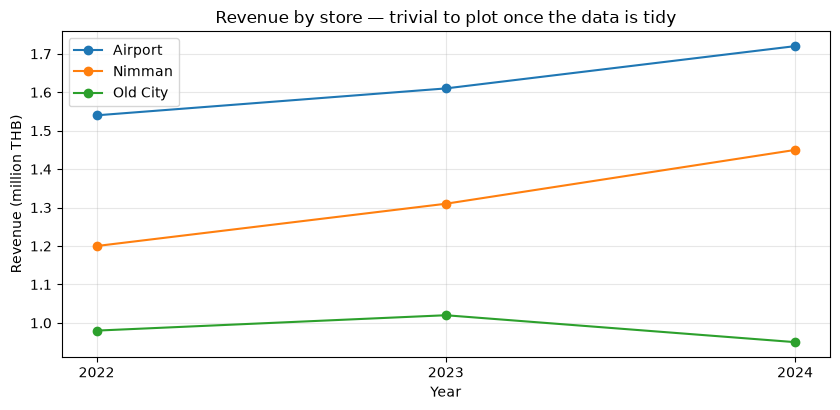

In [24]:
# Why it matters: in tidy form, grouping, filtering, and plotting are all one-liners.
print("Average revenue per year:")
print(tidy.groupby("Year")["Revenue"].mean().apply(lambda v: f"{v:,.0f}").to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for store, group in tidy.groupby("Store"):
    ax.plot(group["Year"], group["Revenue"] / 1e6, marker="o", label=store)
ax.set_xticks(sorted(tidy["Year"].unique()))
ax.set_xlabel("Year")
ax.set_ylabel("Revenue (million THB)")
ax.set_title("Revenue by store — trivial to plot once the data is tidy")
ax.legend()
plt.show()

**How to read it:** the wide table is easier for a human to read; the tidy table is far easier for code to
work with. Grouping by year is impossible in the wide layout without first knowing which columns are years —
in the tidy layout, `Year` is just a column like any other.

The three rules of tidy data:

1. Each **variable** forms a column.
2. Each **observation** forms a row.
3. Each type of **observational unit** forms its own table.

Chapter 6 (Data Preparation) is largely the practice of getting real data into this shape. Learn `.melt()`
(wide → long) and `.pivot()` (long → wide) now and they will serve you for the rest of the course.

> ✏️ **Try it:** the Airport store's revenue rose while Old City's fell. Using the *tidy* table, compute each
> store's percentage change from 2022 to 2024 in one expression. Then try to do the same thing on the wide
> table — which was easier?

---
## 6. Data sources

A **data source** is a place where data originates. Every source is one of two kinds.

- **Primary source** — the data is raw, original, and extracted directly from the source. *You collected it
  yourself.*
- **Secondary source** — data already collected by another person or agency, reused for a valid purpose.

### 6.1 Four ways to collect primary data

Each method trades off cost, control, and how directly it answers your question.

| Method | What it is | Strength | Weakness |
|---|---|---|---|
| **Observation** | Observing and describing a subject's behavior | Records what people *do*, not what they say they do | Cannot reach motives; observer presence can change behavior |
| **Experimental** | Manipulate one or more variables, measure the change in others | The only method that establishes *causation* | Expensive; often impractical or unethical |
| **Interview** | An interviewer questions an interviewee | Deep, flexible, can follow up on surprises | Slow, expensive, hard to scale, interviewer can lead |
| **Survey** | Asking questions of a predefined group | Cheap per response, scales well, easy to analyze | Only captures what you thought to ask; non-response bias |

### 6.2 Three origins of secondary data

Secondary data is already collected — the question is just where it came from.

| Origin | What it is | Example |
|---|---|---|
| **Internal** | Found within the organization itself | Last year's sales figures from your own database |
| **External** | Obtained through third-party resources | A market-research report bought from a research firm |
| **Other** | Collected automatically at scale | Sensor/IoT data, satellite data, web traffic logs |

In [25]:
scenarios = pd.DataFrame({
    "Scenario": [
        "Asking 50 shoppers to fill out a checkout survey",
        "Buying a market-research report from a research firm",
        "A smart thermostat logging temperature every minute",
        "A researcher running a controlled A/B pricing test",
        "Pulling last year's sales figures from your own company database",
        "Watching which aisle shoppers visit first, without speaking to them",
        "Downloading census tables from the national statistics office",
        "Sitting down with 8 customers for an hour each to discuss the app",
    ],
    "Source type": ["Primary", "Secondary", "Secondary", "Primary",
                    "Secondary", "Primary", "Secondary", "Primary"],
    "Method / origin": ["Survey method", "External source", "Sensor data (other)",
                        "Experimental method", "Internal source", "Observation method",
                        "External source", "Interview method"],
})
scenarios

,Scenario,Source type,Method / origin
0,Asking 50 shoppers to fill out a checkout survey,Primary,Survey method
1,Buying a market-research report from a researc...,Secondary,External source
2,A smart thermostat logging temperature every m...,Secondary,Sensor data (other)
3,A researcher running a controlled A/B pricing ...,Primary,Experimental method
4,Pulling last year's sales figures from your ow...,Secondary,Internal source
5,"Watching which aisle shoppers visit first, wit...",Primary,Observation method
6,Downloading census tables from the national st...,Secondary,External source
7,Sitting down with 8 customers for an hour each...,Primary,Interview method


**How to read it:** the same underlying question — *what do customers think of our checkout process?* — could
be answered by a **primary** survey you run yourself or a **secondary** market report someone else compiled.
The label depends on **who collected it and how**, not on the topic.

Note row 3. A thermostat you own, logging your own building, still counts as secondary in the lecture's
framing, because the data was generated by a device for its own purposes rather than collected by a researcher
to answer a research question. The boundary here is genuinely fuzzy in practice; what matters is that you can
articulate *how the data came to exist*.

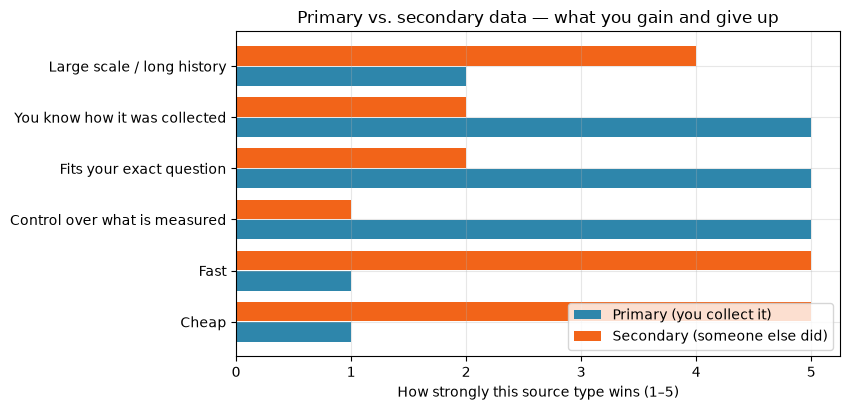

In [26]:
# The trade-off, at a glance. 5 = strongly favors that source type.
tradeoff = pd.DataFrame({
    "Primary": [1, 1, 5, 5, 5, 2],
    "Secondary": [5, 5, 1, 2, 2, 4],
}, index=["Cheap", "Fast", "Control over what is measured",
          "Fits your exact question", "You know how it was collected", "Large scale / long history"])

fig, ax = plt.subplots(figsize=(8.6, 4.2))
y = np.arange(len(tradeoff))
ax.barh(y - 0.2, tradeoff["Primary"], 0.38, label="Primary (you collect it)", color="#2E86AB")
ax.barh(y + 0.2, tradeoff["Secondary"], 0.38, label="Secondary (someone else did)", color="#F26419")
ax.set_yticks(y, tradeoff.index)
ax.set_xlabel("How strongly this source type wins (1–5)")
ax.set_title("Primary vs. secondary data — what you gain and give up")
ax.set_xticks(range(6))
ax.legend(loc="lower right")
plt.show()

**How to read it:** the two bars are near mirror images, which is the honest summary of the trade-off. Primary
data fits your question exactly and you know its provenance, but it costs time and money and is usually small.
Secondary data is cheap, fast, and often vast — and it was collected to answer somebody else's question, using
definitions you did not choose and may not fully know.

**The practical rule:** start with secondary data to understand the landscape and to check whether the question
has already been answered; collect primary data when the specific answer you need does not exist yet. And
whenever you use secondary data, find out how it was defined — a "customer" in someone else's database may not
be a customer in yours.

---
## 7. Sampling — how the data was collected can outweigh how much of it there is

This section is not on the slides, but it belongs here, because it is the point where everything above becomes
consequential.

A **population** is everyone or everything you want to conclude about. A **sample** is the subset you actually
measured. A **sampling frame** is the list you drew the sample from — and the gap between the frame and the
population is where most disasters live.

The seductive error of the big-data era is believing that a very large sample fixes a biased one. It does not.

In [27]:
# A population of 20,000 students and their monthly spending on food.
population = pd.Series(rng.gamma(shape=6.0, scale=800, size=20_000))
true_mean = population.mean()

# Sample 1: a small SIMPLE RANDOM sample — every student equally likely.
random_sample = population.sample(200, random_state=1)

# Sample 2: a big VOLUNTARY sample — 5,000 responses, but students who spend more
# are more likely to bother answering a survey about food spending.
response_probability = (population / population.max()) ** 0.7
responded = rng.random(len(population)) < response_probability * 0.55
voluntary_sample = population[responded]

summary = pd.DataFrame({
    "n": [len(population), len(random_sample), len(voluntary_sample)],
    "Mean spending (THB)": [true_mean, random_sample.mean(), voluntary_sample.mean()],
}, index=["True population", "Random sample", "Voluntary sample"])
summary["Error vs. truth"] = (summary["Mean spending (THB)"] - true_mean)
summary["Error %"] = (summary["Error vs. truth"] / true_mean * 100).round(1)
summary.round(0)

,n,Mean spending (THB),Error vs. truth,Error %
True population,20000,4784.0,0.0,0.0
Random sample,200,4684.0,-99.0,-2.0
Voluntary sample,4205,5362.0,578.0,12.0


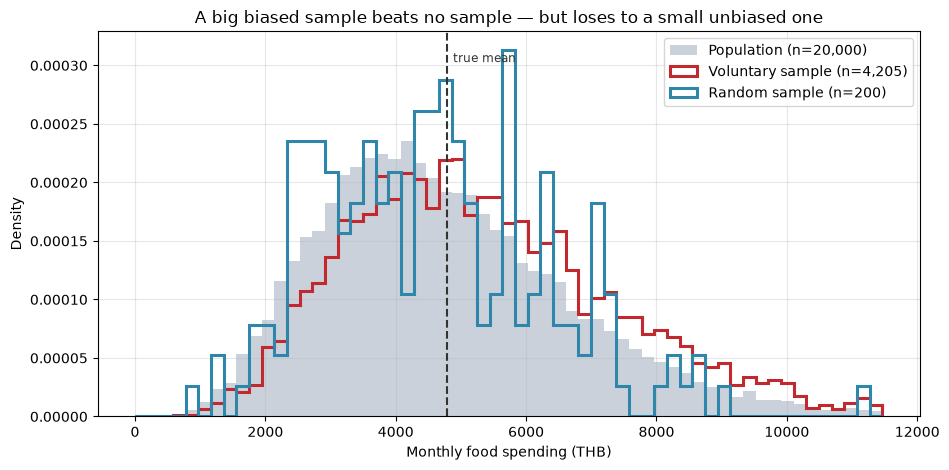

In [28]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))
bins = np.linspace(0, population.quantile(0.995), 60)
ax.hist(population, bins=bins, density=True, alpha=0.45, color="#8D99AE", label=f"Population (n={len(population):,})")
ax.hist(voluntary_sample, bins=bins, density=True, histtype="step", linewidth=2.2,
        color="#C1292E", label=f"Voluntary sample (n={len(voluntary_sample):,})")
ax.hist(random_sample, bins=bins, density=True, histtype="step", linewidth=2.2,
        color="#2E86AB", label=f"Random sample (n={len(random_sample):,})")
ax.axvline(true_mean, color="#333", linestyle="--", linewidth=1.5)
ax.text(true_mean * 1.02, ax.get_ylim()[1] * 0.92, "true mean", fontsize=8.5, color="#333")
ax.set_xlabel("Monthly food spending (THB)")
ax.set_ylabel("Density")
ax.set_title("A big biased sample beats no sample — but loses to a small unbiased one")
ax.legend()
plt.show()

**How to read it:** the small random sample of 200 tracks the true population closely. The voluntary sample —
**more than twenty times larger** — is visibly shifted to the right, because the students who bothered to
respond were disproportionately the ones who spend a lot. Its error does not shrink with more responses; it is
**locked in by the way responses were selected**, and collecting 50,000 instead of 5,000 would reproduce the
same wrong answer with greater confidence.

This is the single most important idea in this chapter:

> **A large sample reduces random error. It does nothing whatsoever about systematic error.**

Famous instances: the 1936 *Literary Digest* poll surveyed 2.4 million people and called the US presidential
election wrongly, because its sampling frame — telephone and car-registration lists — over-represented the
wealthy. Web analytics measure only people who reached your site. App reviews come almost entirely from users
who were delighted or furious.

When you meet a dataset, ask **"who is missing from this table, and why?"** before you ask anything else.

> ✏️ **Try it:** change the exponent `** 0.7` to `** 0.1`, which makes response probability much flatter
> across spending levels. Re-run both cells. What happens to the voluntary sample's error, and what does that
> tell you about which property of a sample actually matters?

---
## 8. Data ethics and personal data

Some of the most useful data describes identifiable people, and that changes what you are allowed and obliged
to do with it. In Thailand this is governed by the **Personal Data Protection Act (PDPA, B.E. 2562)**; the
European **GDPR** is the international reference that most policies are modeled on. The principles are broadly
shared:

| Principle | What it means in practice |
|---|---|
| **Lawful basis** | You need a reason recognized in law — usually consent, contract, or legitimate interest |
| **Purpose limitation** | Data collected for one purpose may not be quietly reused for another |
| **Data minimization** | Collect what you need for the stated purpose, not everything you could |
| **Accuracy** | Wrong data about a person causes real harm; there is a duty to correct it |
| **Storage limitation** | Keep it only as long as the purpose requires |
| **Security** | Protect it proportionately to the harm a leak would cause |
| **Rights of the subject** | People can ask what you hold, correct it, and often have it deleted |

Two technical points that come up constantly in data work:

- **Anonymization is harder than it looks.** Removing names is not enough. A classic result showed that a
  large majority of the US population is uniquely identifiable from just **postal code, birth date, and sex**
  — none of which is a name.
- **Aggregation is not automatically safe.** "Average salary of the 3 people in this department" can reveal an
  individual's salary to the other two.

In [29]:
# Why removing names does not anonymize a dataset.
n_people = 5_000
records = pd.DataFrame({
    "postal_code": rng.choice([50200, 50210, 50300, 50100], n_people),
    "birth_year": rng.integers(1960, 2006, n_people),
    "birth_month": rng.integers(1, 13, n_people),
    "sex": rng.choice(["M", "F"], n_people),
})

# A "quasi-identifier" is a combination of harmless-looking fields.
quasi = ["postal_code", "birth_year", "birth_month", "sex"]
group_sizes = records.groupby(quasi).size()

unique_rows = (group_sizes == 1).sum()
people_in_unique = unique_rows

print(f"Records                                : {n_people:,}")
print(f"Distinct quasi-identifier combinations : {len(group_sizes):,}")
print(f"Combinations matching exactly ONE person: {unique_rows:,}")
print(f"\nSo {people_in_unique / n_people:.1%} of people are uniquely identified by")
print("postal code + birth month + birth year + sex alone — with no name in the file at all.")

Records                                : 5,000
Distinct quasi-identifier combinations : 3,013
Combinations matching exactly ONE person: 1,644

So 32.9% of people are uniquely identified by
postal code + birth month + birth year + sex alone — with no name in the file at all.


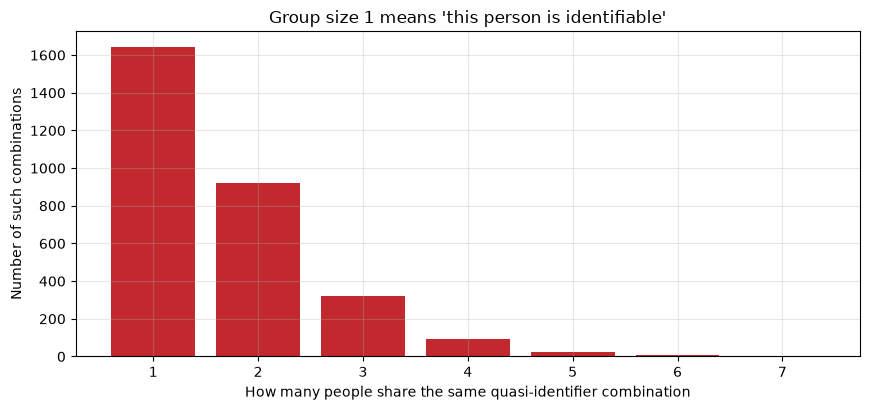

In [30]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
size_counts = group_sizes.value_counts().sort_index()
ax.bar(size_counts.index[:12], size_counts.values[:12], color="#C1292E")
ax.set_xlabel("How many people share the same quasi-identifier combination")
ax.set_ylabel("Number of such combinations")
ax.set_title("Group size 1 means 'this person is identifiable'")
ax.set_xticks(size_counts.index[:12])
plt.show()

**How to read it:** the tall bar at group size 1 counts the combinations that pick out exactly one person. For
each of those, an attacker who knows a target's postal code, birth month and year, and sex can find their row —
and then read every other column in it, including whatever sensitive value the file was supposedly protecting.

The mitigation is called **k-anonymity**: coarsen the quasi-identifiers (birth *year* only instead of month,
province instead of postal code) until every combination matches at least *k* people. It costs you precision,
and that cost is the point — privacy and detail genuinely trade off against each other, and pretending
otherwise is how leaks happen.

> ✏️ **Try it:** drop `birth_month` from the `quasi` list and re-run. How many people remain uniquely
> identifiable? Now drop `postal_code` too. Each field you coarsen buys privacy and loses analytical power.

---
## 9. Glossary

| Term | Meaning |
|---|---|
| **Data** | Raw, unprocessed facts or figures, obtained by observation or measurement |
| **DIKW** | Data → Information → Knowledge → Wisdom |
| **Support / confidence / lift** | How often a pair occurs / how often B follows A / whether that beats chance |
| **Quantitative** | Numerical data: values or counts |
| **Qualitative** | Categorical data: types, labels, codes |
| **Discrete** | Countable numeric values, with gaps between them |
| **Continuous** | Numeric values that can take any value on an interval |
| **Nominal** | Categories with no natural order |
| **Ordinal** | Categories with a natural order but no defined distance |
| **Binary / dichotomous** | A nominal variable with exactly two categories; its mean is a proportion |
| **Interval** | Ordered, equal intervals, no true zero — differences valid, ratios not |
| **Ratio** | Ordered, equal intervals, true zero — differences and ratios both valid |
| **True zero** | A zero meaning "none of the quantity," not a chosen reference point |
| **Observation** | One row: the person or thing measured |
| **Variable** | One column: a measured characteristic |
| **Data matrix** | Observations as rows, variables as columns — a `DataFrame` |
| **Tidy data** | One variable per column, one observation per row, one value per cell |
| **Primary source** | Data you collected yourself (observation, experiment, interview, survey) |
| **Secondary source** | Data collected by someone else (internal, external, or automatic) |
| **Population / sample / sampling frame** | Everyone you want to conclude about / who you measured / the list you drew from |
| **Selection bias** | Systematic error from *how* the sample was chosen; not reduced by a bigger sample |
| **Quasi-identifier** | A combination of non-identifying fields that together identify a person |
| **PDPA** | Thailand's Personal Data Protection Act, B.E. 2562 |

---
## 10. Check your understanding

Try each before opening the answer.

**Q1.** Is a jersey number (the number on a football player's shirt) quantitative or qualitative? What is its
scale?

<details><summary>Answer</summary>

Qualitative, nominal. It is written with digits, but the digits are a label — player 10 is not "twice" player
5, and there is no meaningful average jersey number. This is the same trap as postal codes.
</details>

**Q2.** A shop finds that 85% of customers who buy shampoo also buy a plastic bag, and concludes it should
place bags next to shampoo. What did they forget to check?

<details><summary>Answer</summary>

The lift. If 85% of *all* customers buy a bag, then buying shampoo tells you nothing — confidence is high but
lift ≈ 1. They should compare P(bag | shampoo) against P(bag) before moving anything.
</details>

**Q3.** Are exam scores discrete or continuous?

<details><summary>Answer</summary>

It depends on the exam, and saying so is the right answer. A test marked in whole points out of 100 is
strictly discrete, but with 101 possible values it is almost always *treated* as continuous. A score computed
as a percentage with decimals is continuous. The type is a property of the measurement, not of the concept.
</details>

**Q4.** Is 2024 twice as late as 1012? Which scale explains your answer?

<details><summary>Answer</summary>

No. Calendar years are an interval scale — year zero is a convention, not the beginning of time. Differences
are valid (1012 years apart) but ratios are not, exactly as with Celsius.
</details>

**Q5.** A satisfaction survey has mean 3.0 out of 5. Can you conclude that customers are neutral?

<details><summary>Answer</summary>

No. Section 4.2 showed two datasets with an identical mean of 3.0: one where everybody was neutral and one
split evenly between 1s and 5s. Look at the distribution, and prefer the median (or the full bar chart) for
ordinal data.
</details>

**Q6.** A table has 12 columns and 4,300 rows. How many observations and variables does it have?

<details><summary>Answer</summary>

4,300 observations and 12 variables — *if* the table is tidy. If the columns are years (2013, 2014, …) then
"year" is really a variable whose values have been spread across headers, and the true observation count is
higher. Check the shape of the table, not just `.shape`.
</details>

**Q7.** You have 500,000 product reviews from your website. Is this a good sample of your customers' opinions?

<details><summary>Answer</summary>

Almost certainly not, no matter how large it is. Reviewers self-select, and people who were delighted or
furious are far more likely to write one than the satisfied majority. This is voluntary-response bias, and
Section 7 showed that sample size does nothing to fix it.
</details>

**Q8.** Your dataset contains postal code, birth date, and sex, but no names. Is it anonymous?

<details><summary>Answer</summary>

No. Those three fields form a quasi-identifier that uniquely picks out a large fraction of people. To claim
anonymity you would need to coarsen them until every combination matches at least *k* individuals.
</details>

**Q9.** You want to know whether a new store layout increases sales. Which primary collection method can
establish that the layout *caused* the change, and why can the others not?

<details><summary>Answer</summary>

The experimental method — change the layout in some stores and not in others, at random, then compare.
Observation, interviews, and surveys can all reveal an association, but none of them rules out the possibility
that the stores which got the new layout differed in some other way to begin with.
</details>

---
## 11. Summary — key takeaways

1. **Data climbs to wisdom.** The DIKW pyramid: raw facts → structured information → actionable knowledge → a
   values-based decision. Each step adds meaning, not volume.
2. **Judge a rule on three numbers, not one.** Support, confidence, and lift. Confidence without lift is how
   people talk themselves into acting on coincidence.
3. **Numbers vs. categories.** Quantitative data is counted or measured; qualitative data is labeled.
4. **Discrete vs. continuous.** Can a value halfway between two observed values exist? That question sorts
   every numeric variable.
5. **Nominal vs. ordinal.** Only ordinal categories have a natural order you can rank — declare it explicitly,
   or your charts will sort alphabetically and lie to you.
6. **Scale limits the math.** Mode for nominal; median for ordinal; mean for interval; ratios only for ratio
   data. Your software will not stop you from computing a meaningless average.
7. **Interval has no true zero.** 30 °C is not twice as hot as 15 °C — converting to Kelvin proves it.
8. **Observations are rows, variables are columns**, and tidy data (one value per cell) makes everything
   downstream easier.
9. **Primary vs. secondary.** Collected fresh by you, or reused from someone else — with an honest trade-off
   between fit and cost.
10. **How you sampled outweighs how much you sampled.** A large biased sample is a confident wrong answer.
11. **Personal data carries obligations**, and removing names does not make a dataset anonymous.

### Where this goes next

- **Chapter 3 — Big Data**: the V's — volume, velocity, variety, veracity, value — formalizing what makes data
  "big."
- **Chapter 6 — Data Preparation**: getting real, messy data into the tidy shape from Section 5.1.
- **Chapter 7 — Data Visualization**: choosing a chart that matches the data type from Section 3.
- **Chapter 8 — Statistics and Probability**: what you may legitimately compute, given the scales in Section 4.

### Further reading

The lecture's own sources:

1. *Data* — Wikipedia.
2. *What is the Data, Information, Knowledge, Wisdom (DIKW) pyramid?*
3. Moursund, D., et al. (2006). *Developing a philosophy of computers in education.*
4. *DIKW pyramid* — Wikipedia.
5. *Categorical and numerical types of data* — 365 Data Science.
6. *Types of data in statistics* — nominal, ordinal, discrete, continuous.
7. *Experimental unit — definition, example and facts*; *Data matrix*.
8. *Different sources of data for data analysis* — GeeksforGeeks.
9. *An overview of data collection: data sources and data mining.*
10. *Survey methods: definition, types, and examples*; *Why do companies collect data?*

Beyond the slides:

11. Wickham, H. (2014). *Tidy Data*, Journal of Statistical Software — the source of Section 5.1.
12. Stevens, S. S. (1946). *On the theory of scales of measurement*, Science — the original four-scale paper.
13. Thailand's **Personal Data Protection Act B.E. 2562 (2019)** — the legal framework behind Section 8.

## 12. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 🏫 Student Wellness Survey

Run the cell below to generate a small (fictional) student wellness survey with 25 responses. **Do not modify
it** — everyone's numbers must match.

In [31]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)
n = 25

dorm_buildings = hw_rng.choice(["Dorm A", "Dorm B", "Dorm C"], size=n)
stress_level = hw_rng.choice(["Low", "Medium", "High"], size=n)
study_hours_per_week = np.round(hw_rng.uniform(2, 30, n), 1)
num_classes = hw_rng.integers(3, 8, n)
room_temp_f = np.round(hw_rng.normal(72, 3, n), 1)
gpa = np.round(hw_rng.uniform(2.0, 4.0, n), 2)

wellness = pd.DataFrame({
    "student_id": range(1, n + 1),
    "dorm_building": dorm_buildings,
    "stress_level": stress_level,
    "study_hours_per_week": study_hours_per_week,
    "num_classes": num_classes,
    "room_temp_f": room_temp_f,
    "gpa": gpa,
})
wellness.head()

,student_id,dorm_building,stress_level,study_hours_per_week,num_classes,room_temp_f,gpa
0,1,Dorm C,Medium,20.4,7,72.6,3.29
1,2,Dorm B,Low,28.9,4,70.2,3.33
2,3,Dorm B,High,9.7,5,67.3,2.58
3,4,Dorm C,Low,16.2,7,71.4,2.30
4,5,Dorm B,Low,16.2,6,70.8,2.06


---

### Exercise 1 — Quantitative or qualitative?

For each of the 6 variables in `wellness` (excluding `student_id`), state whether it is **quantitative** or
**qualitative**. For the quantitative ones, also say whether it's **discrete** or **continuous**.

In [32]:
# YOUR CODE HERE (Exercise 1)
# (Written analysis -- you can leave this cell empty or use it for scratch work, e.g. wellness.dtypes)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Nominal or ordinal?

`dorm_building` and `stress_level` are both qualitative. Which one is **nominal** and which is **ordinal**?
Build a `pd.Categorical` for `stress_level` with the correct `categories=` order and `ordered=True`, like the
Section 3.2 example, and use it to check whether `"High" > "Low"` evaluates to `True`.

In [33]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Scales of measurement

Identify the **scale of measurement** (nominal / ordinal / interval / ratio) for `room_temp_f` and for
`study_hours_per_week`. For each, state whether it has a true zero, and explain what "zero" would mean for
that variable.

*Hint: does 0°F mean "no temperature"? Does 0 hours mean "no studying"?*

In [34]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — Observations and variables

How many **observations** and how many **variables** does `wellness` have? Confirm your answer with
`.shape`. Then compute the mean of a variable where the mean is **meaningful**, and explain why computing the
mean of `dorm_building` would **not** be meaningful, even though pandas could technically encode it as
numbers.

In [35]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Primary or secondary?

For each scenario below, say whether the data source is **primary** or **secondary**, and name the specific
method/type (interview, survey, observation, experiment / internal, external, sensor, satellite, web
traffic):

1. The university IT department exports last semester's dorm WiFi usage logs from its own servers.
2. A research assistant sits in the dining hall and counts how many students choose a salad vs. a burger.
3. The wellness office buys a national student-stress benchmark report from an external research company.

In [36]:
# YOUR CODE HERE (Exercise 5)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Build your own data matrix

Create a new `pd.DataFrame` with **4 observations** (any 4 students you invent) and **at least 3 variables**,
including at least one nominal, one ordinal, and one ratio-scale variable. Print it, and label which column is
which scale of measurement.

In [37]:
# YOUR CODE HERE (Exercise 6)


**✍️ Your answer to Question 6:**

---

### Bonus — Climb the DIKW pyramid

Using the `wellness` DataFrame: (1) report one piece of raw **data** (a single cell's value), (2) turn it into
**information** by relating two variables (e.g. average `study_hours_per_week` grouped by `stress_level`), (3)
state a **knowledge**-level rule based on the pattern you found, and (4) give a **wisdom**-level
recommendation the university wellness office could act on.

*Hint: `wellness.groupby("stress_level")["study_hours_per_week"].mean()` is a good place to start.*

In [38]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file